# Analisis Exploratorio Ecuador Sales Forecast

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


plt.style.use("ggplot")
plt.rcParams["font.size"] = 15
COLORS = list(sns.color_palette())

---

# 1. Data Preprocessing

In [ ]:
# helper function to print messages
def cprint(title, *args):
    print(
        "="*len(title), title, "="*len(title),
        *args,
        sep="\n",
    )

In [ ]:




train = pd.read_csv('train.csv',parse_dates=["date"])
test = pd.read_csv('test.csv',parse_dates=["date"])
oil = pd.read_csv('oil.csv',parse_dates=["date"]).rename(columns={"dcoilwtico": "oil"})


store = pd.read_csv('stores.csv')

transaction = pd.read_csv('transactions.csv',parse_dates=["date"])
holiday = pd.read_csv('holidays_events.csv',parse_dates=["date"])

Verificación: Existen intervalos faltantes en los datos de entrenamiento.

In [ ]:
num_family = train.family.nunique()
num_store = train.store_nbr.nunique()
num_ts = train.groupby(["store_nbr", "family"]).ngroups
train_start = train.date.min().date()
train_end = train.date.max().date()
num_train_date = train.date.nunique()
train_len = (train_end - train_start).days + 1
test_start = test.date.min().date()
test_end = test.date.max().date()
num_test_date = test.date.nunique()
test_len = (test_end - test_start).days + 1

In [ ]:
cprint(
    "Basic information of data",
    f"Number of family types      : {num_family}",
    f"Number of stores            : {num_store}",
    f"Number of store-family pairs: {num_family * num_store}",
    f"Number of target series     : {num_ts}",
    "",
    f"Number of unique train dates: {num_train_date}",
    f"Train date range            : {train_len} days from {train_start} to {train_end}",
    f"Number of unique test dates : {num_test_date}",
    f"Test date range             : {test_len} days from {test_start} to {test_end}",
)

Basic information of data
Number of family types      : 33
Number of stores            : 54
Number of store-family pairs: 1782
Number of target series     : 1782

Number of unique train dates: 1684
Train date range            : 1688 days from 2013-01-01 to 2017-08-15
Number of unique test dates : 16
Test date range             : 16 days from 2017-08-16 to 2017-08-31


Verificación: Las cuatro fechas faltantes coinciden con el día de Navidad en los distintos años.

Se observa que todas las series objetivo presentan fechas faltantes correspondientes al día de Navidad a lo largo de los distintos años, lo que sugiere que las tiendas podrían permanecer cerradas en esa fecha.

In [ ]:
missing_dates = pd.date_range(train_start, train_end).difference(train.date.unique())
missing_dates = missing_dates.strftime("%Y-%m-%d").tolist()

unique_dp_count = train.groupby(["store_nbr", "family"]).date.count().unique().tolist()

In [ ]:
cprint(
    "Missing gaps in time series",
    f"List incl. unique counts of data points: {unique_dp_count}",
    f"Missing dates                          : {missing_dates}",
)

Missing gaps in time series
List incl. unique counts of data points: [1684]
Missing dates                          : ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


In [ ]:
# reindex training data
multi_idx = pd.MultiIndex.from_product(
    [pd.date_range(train_start, train_end), train.store_nbr.unique(), train.family.unique()],
    names=["date", "store_nbr", "family"],
)
train = train.set_index(["date", "store_nbr", "family"]).reindex(multi_idx).reset_index()

# fill missing values with 0s
train[["sales", "onpromotion"]] = train[["sales", "onpromotion"]].fillna(0.)
train.id = train.id.interpolate(method="linear") # interpolate linearly as a filler for the 'id'

### Verificación: No hay precios del petróleo registrados durante los fines de semana.

In [ ]:
missing_oil_dates = pd.date_range(train_start, test_end).difference(oil.date)
num_missing_oil_dates = len(missing_oil_dates)
num_wknd_missing = (missing_oil_dates.weekday >= 5).sum()
total_num_wknd = (pd.date_range(train_start, test_end).weekday >= 5).sum()

In [ ]:
cprint(
    "Missing oil dates",
    f"Number of missing oil dates: {num_missing_oil_dates}",
    f"Number of weekends missing : {num_wknd_missing}",
    f"Total number of weekends   : {total_num_wknd}",
)

Missing oil dates
Number of missing oil dates: 486
Number of weekends missing : 486
Total number of weekends   : 486


Dado que las tiendas de comestibles también operan durante los fines de semana, resulta necesario estimar los precios del petróleo faltantes si se desea utilizar esta variable en los modelos. Por simplicidad, los valores faltantes de la columna de precios del petróleo se completan mediante interpolación lineal.

In [ ]:
# reindex oil data
oil = oil.merge(
    pd.DataFrame({"date": pd.date_range(train_start, test_end)}),
    on="date",
    how="outer",
).sort_values("date", ignore_index=True)

# fill missing values using linear interpolation
oil.oil = oil.oil.interpolate(method="linear", limit_direction="both")

### Verificación: Existen transacciones faltantes debido tanto a días con ventas nulas como a registros ausentes.

Con 54 tiendas y 1688 fechas de entrenamiento, debería existir un total de 91.152 registros de transacciones. Sin embargo, esta cantidad no coincide con la contenida en el conjunto de datos proporcionado. Puede verificarse fácilmente que los datos de transacciones no registran los días con ventas iguales a cero, lo que indica que dichos días, por lo general, no son incorporados en la base. En consecuencia, para los días sin ventas, la columna de transacciones se completa con valores de 0.

Luego de realizar este ajuste, se observa que aún persisten valores faltantes, lo que sugiere la existencia de datos efectivamente ausentes y no únicamente asociados a días sin ventas. Por simplicidad, los valores faltantes restantes se completan mediante interpolación lineal.

In [ ]:
num_zero_sales = (train.groupby(["date", "store_nbr"]).sales.sum().eq(0)).sum()
total_rec = num_store * train_len
curr_rec = len(transaction.index)
missing_rec = total_rec - curr_rec - num_zero_sales

In [ ]:
cprint(
    "Missing transaction records",
    f"Correct number of records: {total_rec}",
    "",
    "Breakdown...",
    f"Current number of records: {curr_rec}",
    f"Number of zero sales     : {num_zero_sales}",
    f"Number of missing records: {missing_rec}",
)

Missing transaction records
Correct number of records: 91152

Breakdown...
Current number of records: 83488
Number of zero sales     : 7546
Number of missing records: 118


In [ ]:
# compute total sales for each store
store_sales = train.groupby(["date", "store_nbr"]).sales.sum().reset_index()

# reindex transaction data
transaction = transaction.merge(
    store_sales,
    on=["date", "store_nbr"],
    how="outer",
).sort_values(["date", "store_nbr"], ignore_index=True)

# fill missing values with 0s for days with zero sales
transaction.loc[transaction.sales.eq(0), "transactions"] = 0.
transaction = transaction.drop(columns=["sales"])

# fill remaining missing values using linear interpolation
transaction.transactions = transaction.groupby("store_nbr", group_keys=False).transactions.apply(
    lambda x: x.interpolate(method="linear", limit_direction="both")
)

### Analisis de Festividades

In [ ]:
national_locale_name = sorted(holiday[holiday.locale.eq("National")].locale_name.unique().tolist())
regional_locale_name = sorted(holiday[holiday.locale.eq("Regional")].locale_name.unique().tolist())
local_locale_name = sorted(holiday[holiday.locale.eq("Local")].locale_name.unique().tolist())

In [ ]:
cprint(
    "List of locale names for each holiday",
    "Locale names for national holidays:",
    national_locale_name,
    "",
    "Locale names for regional holidays:",
    regional_locale_name,
    "",
    "Locale names for local holidays:",
    local_locale_name,
)

List of locale names for each holiday
Locale names for national holidays:
['Ecuador']

Locale names for regional holidays:
['Cotopaxi', 'Imbabura', 'Santa Elena', 'Santo Domingo de los Tsachilas']

Locale names for local holidays:
['Ambato', 'Cayambe', 'Cuenca', 'El Carmen', 'Esmeraldas', 'Guaranda', 'Guayaquil', 'Ibarra', 'Latacunga', 'Libertad', 'Loja', 'Machala', 'Manta', 'Puyo', 'Quevedo', 'Quito', 'Riobamba', 'Salinas', 'Santo Domingo']


In [ ]:
holiday[(holiday.description.str.contains("Navidad"))&(holiday.date.dt.year.eq(2012))]

,date,type,locale,locale_name,description,transferred
31,2012-12-21,Additional,National,Ecuador,Navidad-4,False
33,2012-12-22,Additional,National,Ecuador,Navidad-3,False
34,2012-12-23,Additional,National,Ecuador,Navidad-2,False
35,2012-12-24,Bridge,National,Ecuador,Puente Navidad,False
36,2012-12-24,Additional,National,Ecuador,Navidad-1,False
37,2012-12-25,Holiday,National,Ecuador,Navidad,False
38,2012-12-26,Additional,National,Ecuador,Navidad+1,False


In [ ]:
def process_holiday(s):
    if "futbol" in s:
        return "futbol"
    to_remove = list(set(store.city.str.lower()) | set(store.state.str.lower()))
    for w in to_remove:
        s = s.replace(w, "")
    return s

In [ ]:
holiday.description = holiday.apply(
    lambda x: x.description.lower().replace(x.locale_name.lower(), ""),
    axis=1,
).apply(
    process_holiday
).replace(
    r"[+-]\d+|\b(de|del|traslado|recupero|puente|-)\b", "", regex=True,
).replace(
    r"\s+|-", " ", regex=True,
).str.strip()

holiday.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,fundacion,False
1,2012-04-01,Holiday,Regional,Cotopaxi,provincializacion,False
2,2012-04-12,Holiday,Local,Cuenca,fundacion,False
3,2012-04-14,Holiday,Local,Libertad,cantonizacion,False
4,2012-04-21,Holiday,Local,Riobamba,cantonizacion,False


Posteriormente, los datos de feriados se procesan eliminando aquellos que fueron trasladados, lo cual puede identificarse mediante la columna transferred. Dado que estos feriados no se celebran en su fecha oficial y, en la práctica, se comportan más como días normales, se opta por excluirlos del análisis.

A continuación, los feriados se separan en nacionales, regionales y locales, además de considerar los sábados designados como días laborables. Para facilitar su diferenciación en etapas posteriores de visualización, se asignan los prefijos nat_ y loc_ a los feriados nacionales y locales, respectivamente. En el caso de los feriados regionales, se observa que únicamente aparece la categoría provincialización, por lo que esta se etiqueta de esa manera.

Un ejemplo de este procedimiento se muestra a continuación, donde los feriados nacionales son codificados como variables dummy. El mismo criterio se aplica al resto de las categorías de feriados.

In [ ]:
# remove transferred holidays
holiday = holiday[holiday.transferred.eq(False)]

#########################################
### Saturdays designated as work days ###
#########################################
work_days = holiday[holiday.type.eq("Work Day")]
work_days = work_days[["date", "type"]].rename(
    columns={"type": "work_day"}
).reset_index(drop=True)
work_days.work_day = work_days.work_day.notna().astype(int)
# remove work days after extracting above
holiday = holiday[holiday.type!="Work Day"].reset_index(drop=True)

###################################
### local holidays (city level) ###
###################################
local_holidays = holiday[holiday.locale.eq("Local")]
local_holidays = local_holidays[["date", "locale_name", "description"]].rename(
    columns={"locale_name": "city"}
).reset_index(drop=True)
local_holidays = local_holidays[~local_holidays.duplicated()]
local_holidays = pd.get_dummies(local_holidays, columns=["description"], prefix="loc")

#######################################
### regional holidays (state level) ###
#######################################
regional_holidays = holiday[holiday.locale.eq("Regional")]
regional_holidays = regional_holidays[["date", "locale_name", "description"]].rename(
    columns={"locale_name": "state", "description": "provincializacion"}
).reset_index(drop=True)
regional_holidays.provincializacion = regional_holidays.provincializacion.eq("provincializacion").astype(int)

#########################
### national holidays ###
#########################
national_holidays = holiday[holiday.locale.eq("National")]
national_holidays = national_holidays[["date", "description"]].reset_index(drop=True)
national_holidays = national_holidays[~national_holidays.duplicated()]
national_holidays = pd.get_dummies(national_holidays, columns=["description"], prefix="nat")
# different national holidays may fall on the same day
national_holidays = national_holidays.groupby("date").sum().reset_index()
# shorten name for visualization purposes later
national_holidays = national_holidays.rename(columns={"nat_primer grito independencia": "nat_primer grito"})

national_holidays.head()

,date,nat_batalla,nat_black friday,nat_carnaval,nat_cyber monday,nat_dia difuntos,nat_dia la madre,nat_dia trabajo,nat_futbol,nat_independencia,nat_navidad,nat_primer dia ano,nat_primer grito,nat_terremoto,nat_viernes santo
0,2012-08-10,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2012-10-12,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,2012-11-02,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,2012-11-03,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,2012-12-21,0,0,0,0,0,0,0,0,0,1,0,0,0,0


---

# 2. Data Exploration

In [ ]:
sales_ts = pd.pivot_table(train, values="sales", index="date", columns=["store_nbr", "family"])
tr_ts = pd.pivot_table(transaction, values="transactions", index="date", columns="store_nbr")
promo_ts = pd.pivot_table(train, values="onpromotion", index="date", columns=["store_nbr", "family"])

sales_ts.head()

store_nbr          1                                                 \
family     AUTOMOTIVE BABY CARE BEAUTY BEVERAGES BOOKS BREAD/BAKERY   
date                                                                  
2013-01-01        0.0       0.0    0.0       0.0   0.0        0.000   
2013-01-02        2.0       0.0    2.0    1091.0   0.0      470.652   
2013-01-03        3.0       0.0    0.0     919.0   0.0      310.655   
2013-01-04        3.0       0.0    3.0     953.0   0.0      198.366   
2013-01-05        5.0       0.0    3.0    1160.0   0.0      301.057   

store_nbr                                        ...        54          \
family     CELEBRATION CLEANING  DAIRY     DELI  ... MAGAZINES   MEATS   
date                                             ...                     
2013-01-01         0.0      0.0    0.0    0.000  ...       0.0   0.000   
2013-01-02         0.0   1060.0  579.0  164.069  ...       0.0  73.771   
2013-01-03         0.0    836.0  453.0  151.582  ...       0.0  50.257   
2013-01-04         0.0    827.0  460.0  131.411  ...       0.0  40.223   
2013-01-05         0.0    811.0  464.0  118.613  ...       0.0  43.431   

store_nbr                                                              \
family     PERSONAL CARE PET SUPPLIES PLAYERS AND ELECTRONICS POULTRY   
date                                                                    
2013-01-01           0.0          0.0                     0.0   0.000   
2013-01-02         228.0          0.0                     0.0  15.514   
2013-01-03         156.0          0.0                     0.0   4.313   
2013-01-04         146.0          0.0                     0.0  26.743   
2013-01-05         205.0          0.0                     0.0  31.118   

store_nbr                                                             
family     PREPARED FOODS PRODUCE SCHOOL AND OFFICE SUPPLIES SEAFOOD  
date                                                                  
2013-01-01            0.0     0.0                        0.0     0.0  
2013-01-02           61.0     0.0                        0.0     3.0  
2013-01-03            1.0     0.0                        0.0     2.0  
2013-01-04           38.0     0.0                        0.0     2.0  
2013-01-05           32.0     0.0                        0.0     1.0  

[5 rows x 1782 columns]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# scale target series
scaler = MinMaxScaler()
sales_ts_scaled = sales_ts.copy()
sales_ts_scaled[sales_ts_scaled.columns] = scaler.fit_transform(sales_ts_scaled)

# convert back to long form and add the holiday columns
holiday_sales_merged = sales_ts_scaled.melt(
    value_name="sales", ignore_index=False,
).reset_index().merge(
    store, on="store_nbr", how="left",
).merge(
    work_days, on="date", how="left",
).merge(
    local_holidays, on=["date", "city"], how="left",
).merge(
    regional_holidays, on=["date", "state"], how="left",
).merge(
    national_holidays, on="date", how="left",
).fillna(0)

# include dummy variable for dates without any holidays
holiday_list = [col for col in holiday_sales_merged if col.startswith(("loc_", "nat_", "provincializacion"))]
holiday_sales_merged["no_holiday"] = holiday_sales_merged[holiday_list].sum(axis=1).eq(0).astype(int)

holiday_sales_merged.head()

,date,store_nbr,family,sales,city,state,type,cluster,work_day,loc_cantonizacion,...,nat_dia la madre,nat_dia trabajo,nat_futbol,nat_independencia,nat_navidad,nat_primer dia ano,nat_primer grito,nat_terremoto,nat_viernes santo,no_holiday
0,2013-01-01,1,AUTOMOTIVE,0.000000,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
1,2013-01-02,1,AUTOMOTIVE,0.105263,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2013-01-03,1,AUTOMOTIVE,0.157895,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2013-01-04,1,AUTOMOTIVE,0.157895,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,2013-01-05,1,AUTOMOTIVE,0.263158,Quito,Pichincha,D,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


En términos generales, la cantidad de ventas iguales a cero presenta una tendencia decreciente a lo largo del tiempo. Asimismo, además de observarse valores elevados durante la Navidad, también se registran cantidades importantes de ventas nulas en Año Nuevo.

/tmp/ipykernel_26088/2147922830.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  high_zero_counts = zero_count_filtered[zero_count_filtered.date.isin(high_zero_dates)].zero_sales_ct.tolist()


Dates with zero sales
Dates (excl. Christmas) with zero sales: ['2013-01-01', '2014-01-01', '2015-01-01', '2016-01-01', '2017-01-01']
Corresponding counts of zero sales     : [1765, 1732, 1759, 1753, 1754]
Total number of target series          : 1782


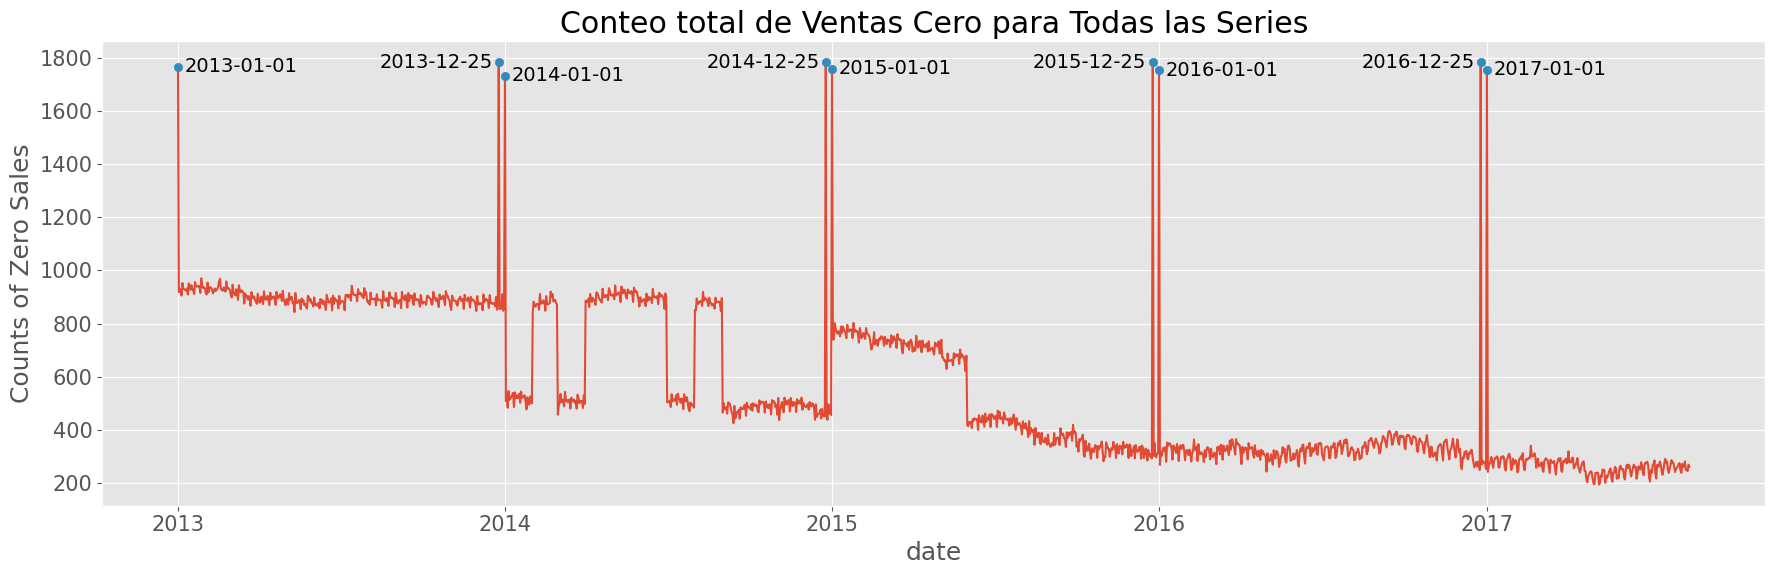

In [ ]:
def plot_zero_count_ts():
    zero_count_ts = (sales_ts.eq(0)).sum(axis=1).to_frame("zero_sales_ct").reset_index()
    zero_count_filtered = zero_count_ts[zero_count_ts.zero_sales_ct.gt(1500)].reset_index(drop=True)
    high_zero_dates = zero_count_filtered.date.dt.strftime("%Y-%m-%d")
    high_zero_dates = [d for d in high_zero_dates if not d.endswith("12-25")]
    high_zero_counts = zero_count_filtered[zero_count_filtered.date.isin(high_zero_dates)].zero_sales_ct.tolist()

    cprint(
        "Dates with zero sales",
        f"Dates (excl. Christmas) with zero sales: {high_zero_dates}",
        f"Corresponding counts of zero sales     : {high_zero_counts}",
        f"Total number of target series          : {num_ts}",
    )

    plt.figure(figsize=(18, 6))

    sns.lineplot(data=zero_count_ts, x="date", y="zero_sales_ct")
    sns.scatterplot(
        data=zero_count_filtered, x="date", y="zero_sales_ct",
        color=COLORS[1],
        edgecolor=COLORS[1],
        zorder=2,
    )
    for j in range(len(zero_count_filtered.index)):
        ha = "left" if j%2==0 else "right"
        offset = pd.Timedelta(7, "d") if ha=="left" else pd.Timedelta(-7, "d")
        plt.text(
            x=zero_count_filtered.date[j]+offset, y=zero_count_filtered.zero_sales_ct[j],
            s=zero_count_filtered.date[j].strftime("%Y-%m-%d"),
            ha=ha,
            va="center",
            size=14,
        )
    plt.ylabel("Counts of Zero Sales")
    plt.title("Conteo total de Ventas Cero para Todas las Series")
    plt.tight_layout()
    plt.show()

plot_zero_count_ts()

Un aspecto relevante es que, al analizar la distribución por tienda, todas presentan aproximadamente entre 0 y 3 series constantes en cero, lo que sugiere que este fenómeno no se concentra de forma desproporcionada en establecimientos específicos.

En cambio, al examinarlo según la familia de productos, se observa que la categoría de libros concentra la mayor cantidad de series constantes en cero.

Constant target series
Number of constant target series: 53
List of unique constant values  : [0.0]


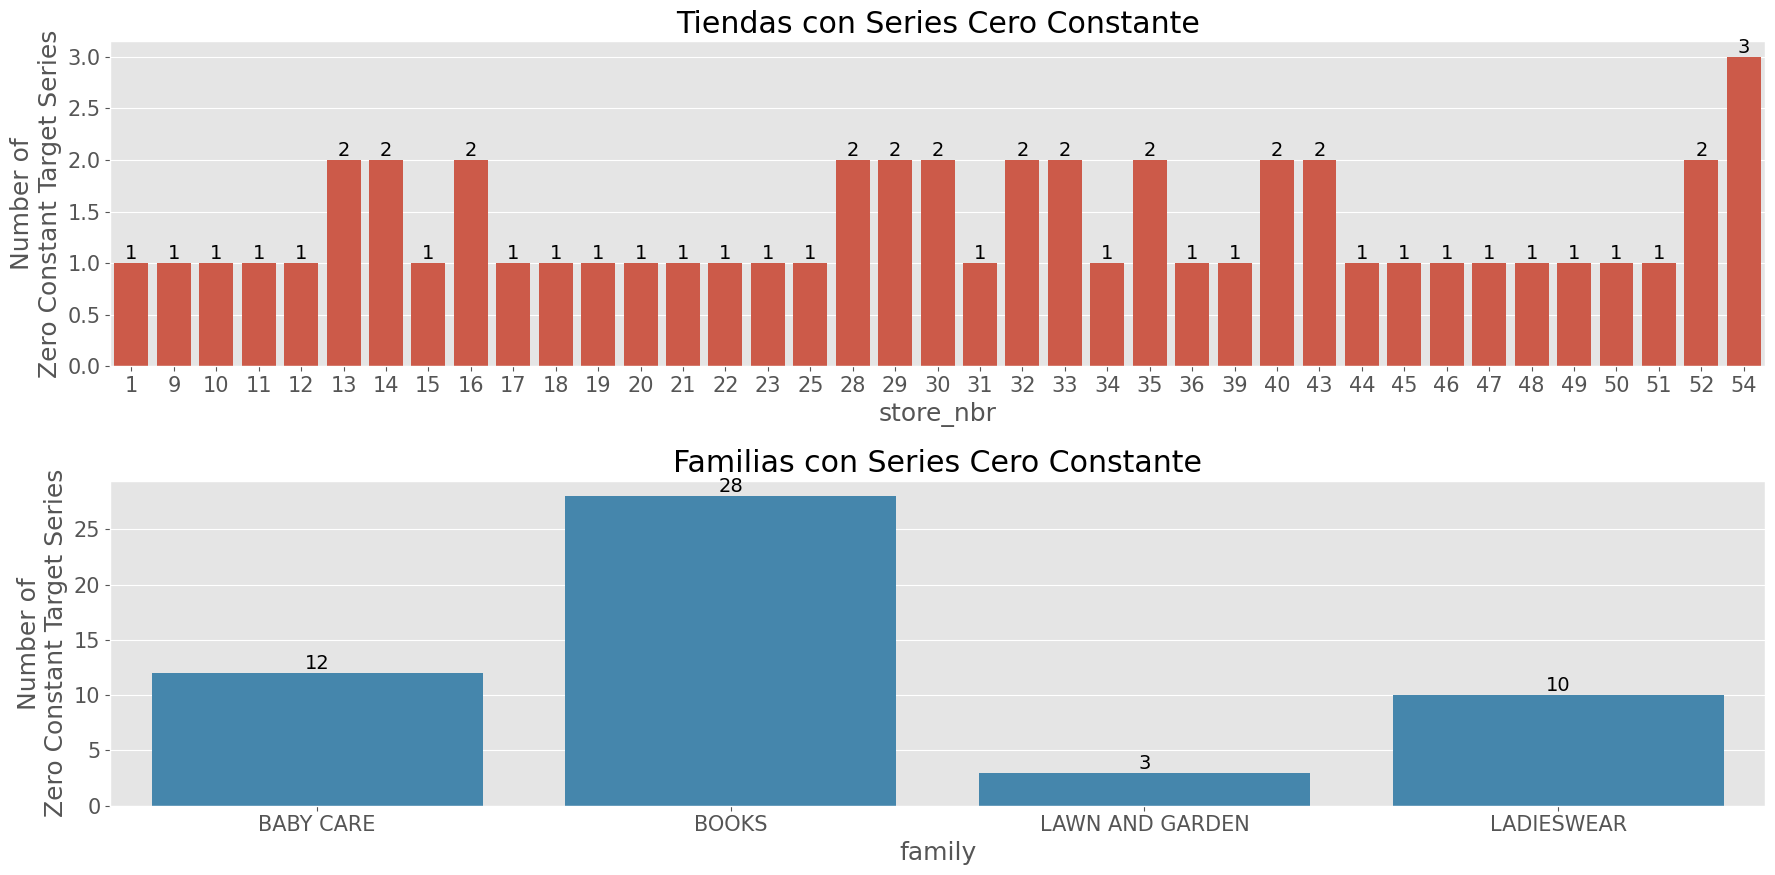

In [ ]:
def plot_constant_ts_distribution():
    const_ts = sales_ts.iloc[:, (sales_ts.std()==0).tolist()]
    const_ts_labels = const_ts.columns.to_frame().reset_index(drop=True)

    cprint(
        "Constant target series",
        f"Number of constant target series: {len(const_ts.columns)}",
        f"List of unique constant values  : {const_ts.iloc[0].unique().tolist()}",
    )

    fig = plt.figure(figsize=(18, 9))

    ax0 = sns.countplot(
        data=const_ts_labels, x="store_nbr",
        color=COLORS[0],
        ax=fig.add_subplot(211),
    )
    ax0.bar_label(ax0.containers[0], size=14)
    plt.ylabel("Number of\nZero Constant Target Series")
    plt.title("Tiendas con Series Cero Constante")

    ax1 = sns.countplot(
        data=const_ts_labels, x="family",
        color=COLORS[1],
        ax=fig.add_subplot(212),
    )
    ax1.bar_label(ax1.containers[0], size=14)
    plt.ylabel("Number of\nZero Constant Target Series")
    plt.title("Familias con Series Cero Constante")

    plt.tight_layout()
    plt.show()

plot_constant_ts_distribution()

El gráfico de barras apiladas correspondiente muestra la cantidad de tiendas en cada provincia, identificadas mediante su número de tienda y diferenciadas por colores según la ciudad a la que pertenecen. Por ejemplo, en la provincia de Manabí, la tienda número 54 corresponde a una ciudad, mientras que las tiendas 52 y 53 pertenecen a otra. Esta representación permite observar la distribución territorial de los establecimientos dentro de cada provincia.

Static covariates: city, state
Number of unique cities                      : 22
Number of unique states                      : 16
Number of states with stores in only one city: 12


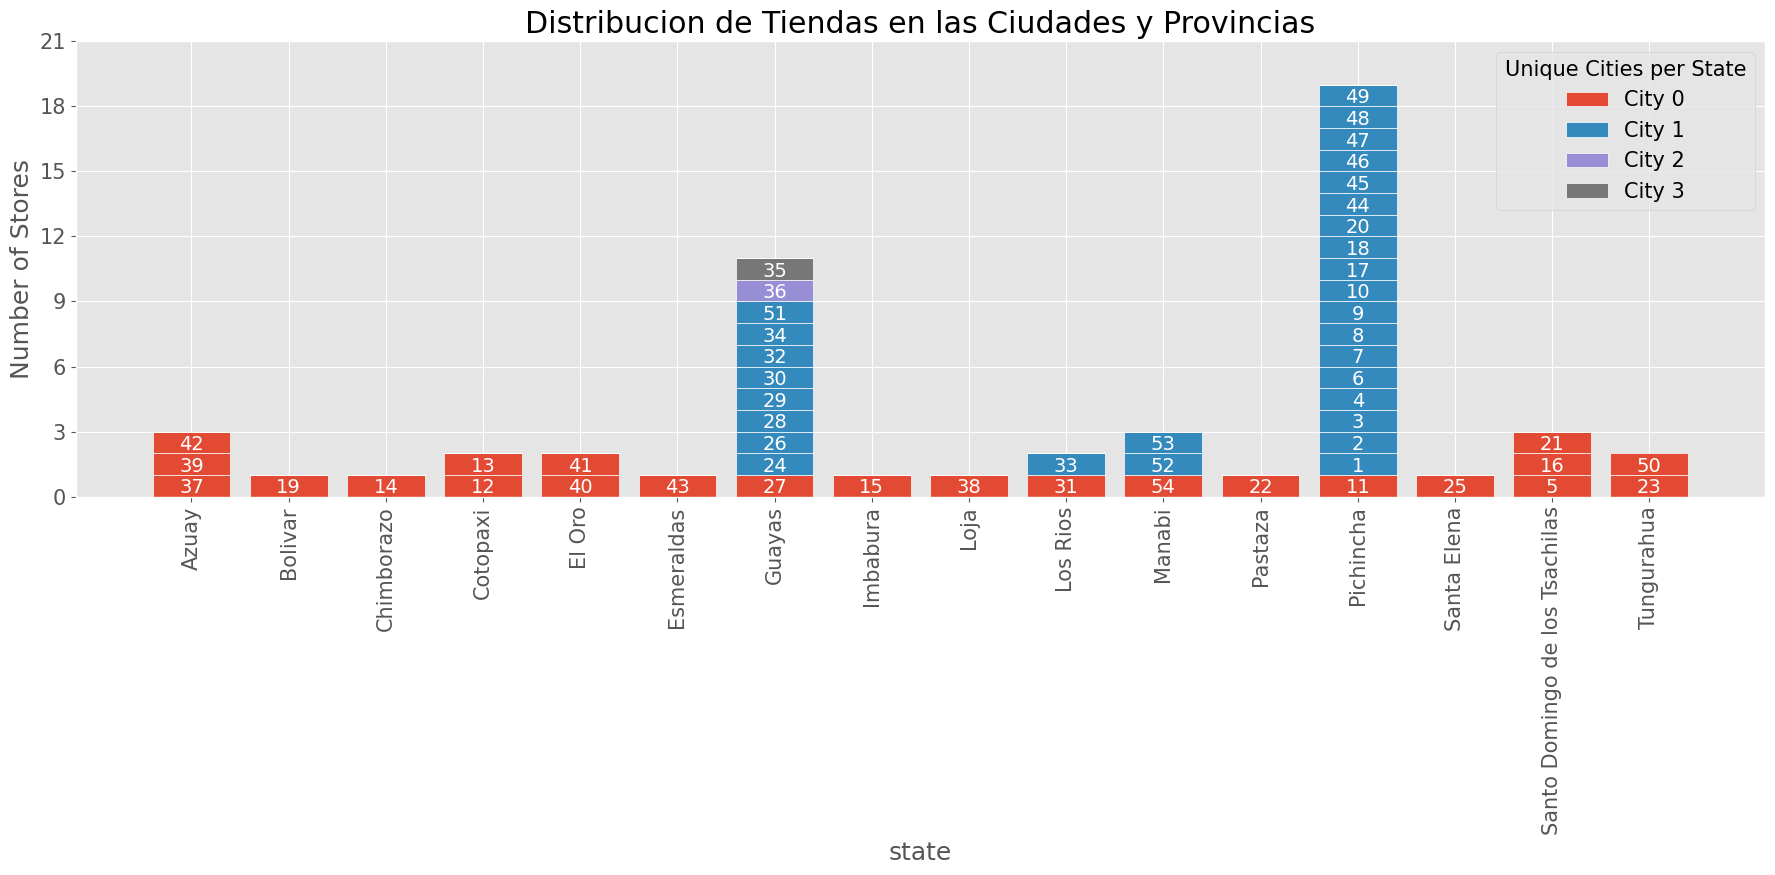

In [ ]:
def plot_city_state_distribution(store):
    cprint(
        "Static covariates: city, state",
        f"Number of unique cities                      : {store.city.nunique()}",
        f"Number of unique states                      : {store.state.nunique()}",
        f"Number of states with stores in only one city: {(store.groupby('state').city.nunique().eq(1)).sum()}",
    )

    store = store.copy().sort_values(["state", "city", "store_nbr"])
    state_list = store.state.unique()
    bar_bottom = np.zeros(len(state_list))
    counter = {}

    fig = plt.figure(figsize=(18, 9))

    for num in store.store_nbr.unique():
        curr_state, curr_city = store.loc[store.store_nbr.eq(num), ["state", "city"]].values[0]
        if curr_state not in counter:
            counter[curr_state] = []
        if curr_city not in counter[curr_state]:
            counter[curr_state].append(curr_city)
        state_ind = (state_list==curr_state).astype(int)
        plt.bar(
            x=state_list, height=state_ind,
            bottom=bar_bottom,
            color=COLORS[len(counter[curr_state])-1],
            edgecolor="white",
            label=f"City {len(counter[curr_state])-1}",
        )
        bar_bottom += state_ind
        running_total = bar_bottom[np.argmax(state_ind)]
        plt.text(
            x=curr_state, y=running_total-0.6,
            s=num,
            size=14,
            color="white",
            va="center",
            ha="center",
        )
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = sorted(list(set(labels)))
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    plt.legend(unique_handles, unique_labels, title="Unique Cities per State")
    plt.xticks(rotation=90)
    plt.yticks(list(range(0, 22, 3)))
    plt.xlabel("state")
    plt.ylabel("Number of Stores")
    plt.title("Distribucion de Tiendas en las Ciudades y Provincias")

    plt.tight_layout()
    plt.show()

plot_city_state_distribution(store)

Estudio de Venta en el tiempo y comparativa con oil, promociones y transacciones

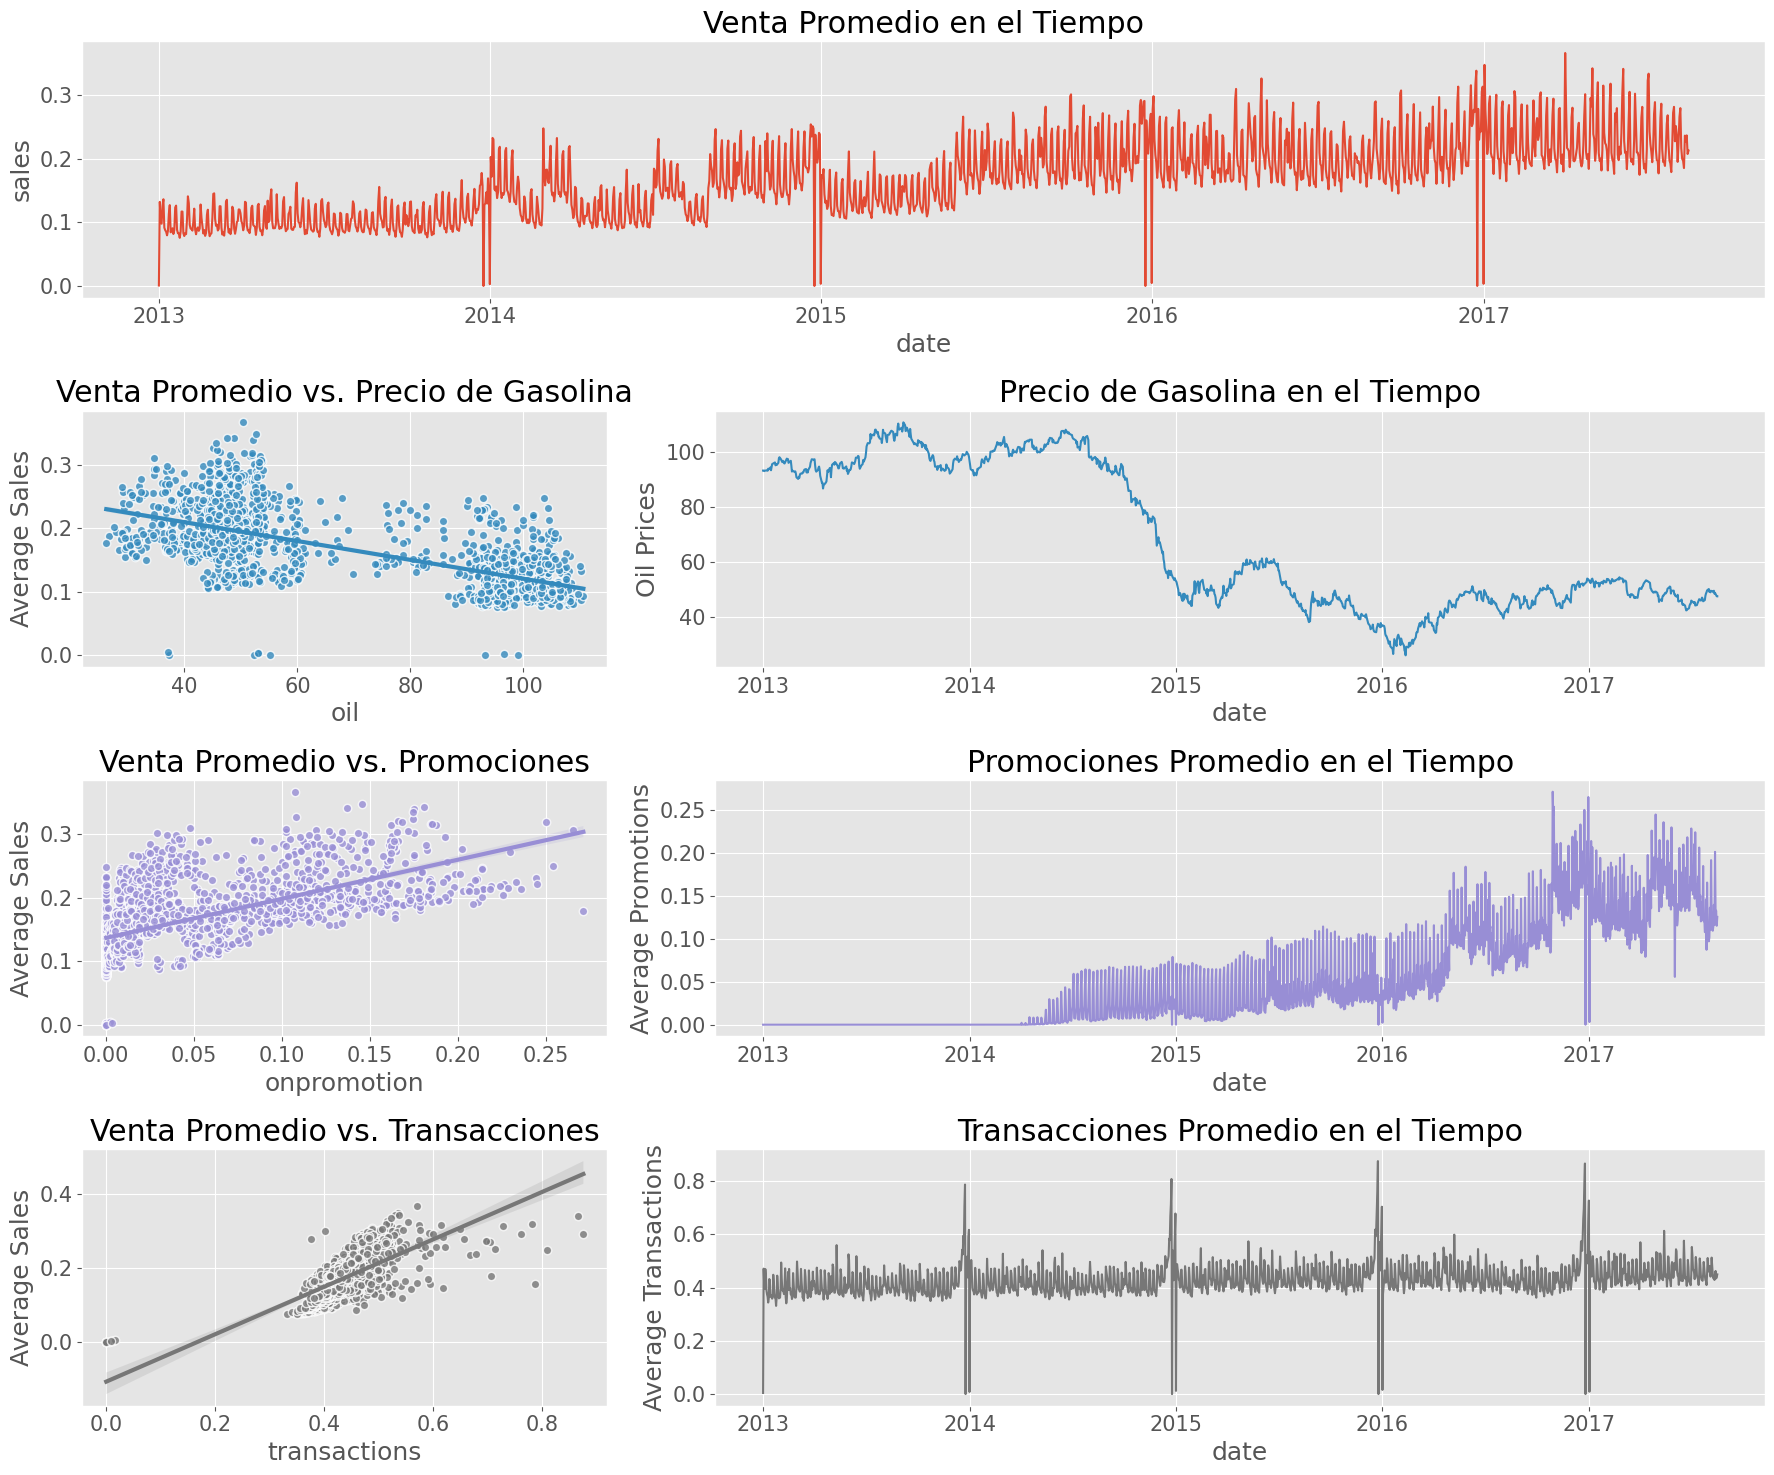

In [ ]:
def plot_sales_correlation():
    tr_ts_scaled = tr_ts.copy()
    tr_ts_scaled[tr_ts_scaled.columns] = scaler.fit_transform(tr_ts_scaled)

    promo_ts_scaled = promo_ts.copy()
    promo_ts_scaled[promo_ts_scaled.columns] = scaler.fit_transform(promo_ts_scaled)

    mean_sales_ts_scaled = sales_ts_scaled.mean(axis=1).to_frame("sales").reset_index()
    mean_promo_ts_scaled = promo_ts_scaled.mean(axis=1).to_frame("onpromotion").reset_index()
    mean_tr_ts_scaled = tr_ts_scaled.mean(axis=1).to_frame("transactions").reset_index()


    plot_kwargs = {
        "scatter_kws": {"edgecolor": "white"},
        "line_kws": {"lw": 3},
    }

    fig = plt.figure(figsize=(18, 15))
    gs = fig.add_gridspec(4, 2, width_ratios=(1, 2))

    sns.lineplot(
        data=mean_sales_ts_scaled,
        x="date",
        y="sales",
        ax=fig.add_subplot(gs[0, :]),
    )
    plt.title("Venta Promedio en el Tiempo")

    sns.regplot(
        x=oil.oil.iloc[:train_len], y=mean_sales_ts_scaled.sales,
        ax=fig.add_subplot(gs[1, 0]),
        color=COLORS[1],
        **plot_kwargs,
    )
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio vs. Precio de Gasolina")

    sns.lineplot(
        data=oil.iloc[:train_len, :], x="date", y="oil",
        ax=fig.add_subplot(gs[1, 1]),
        color=COLORS[1],
    )
    plt.ylabel("Oil Prices")
    plt.title("Precio de Gasolina en el Tiempo")

    sns.regplot(
        x=mean_promo_ts_scaled.onpromotion, y=mean_sales_ts_scaled.sales,
        ax=fig.add_subplot(gs[2, 0]),
        color=COLORS[2],
        **plot_kwargs,
    )
    plt.xlabel("onpromotion")
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio vs. Promociones")

    sns.lineplot(
        data=mean_promo_ts_scaled, x="date", y="onpromotion",
        ax=fig.add_subplot(gs[2, 1]),
        color=COLORS[2],
    )
    plt.ylabel("Average Promotions")
    plt.title("Promociones Promedio en el Tiempo")

    sns.regplot(
        x=mean_tr_ts_scaled.transactions, y=mean_sales_ts_scaled.sales,
        ax=fig.add_subplot(gs[3, 0]),
        color=COLORS[3],
        **plot_kwargs,
    )
    plt.xlabel("transactions")
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio vs. Transacciones")

    sns.lineplot(
        data=mean_tr_ts_scaled, x="date", y="transactions",
        ax=fig.add_subplot(gs[3, 1]),
        color=COLORS[3],
    )
    plt.ylabel("Average Transactions")
    plt.title("Transacciones Promedio en el Tiempo")

    plt.tight_layout()
    plt.show()

plot_sales_correlation()

Estudio de festividaes a nivel nacional, regional y local

/tmp/ipykernel_26088/1055156067.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_26088/1055156067.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_26088/1055156067.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_26088/1055156067.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_26088/1055156067.py:43: FutureWarning

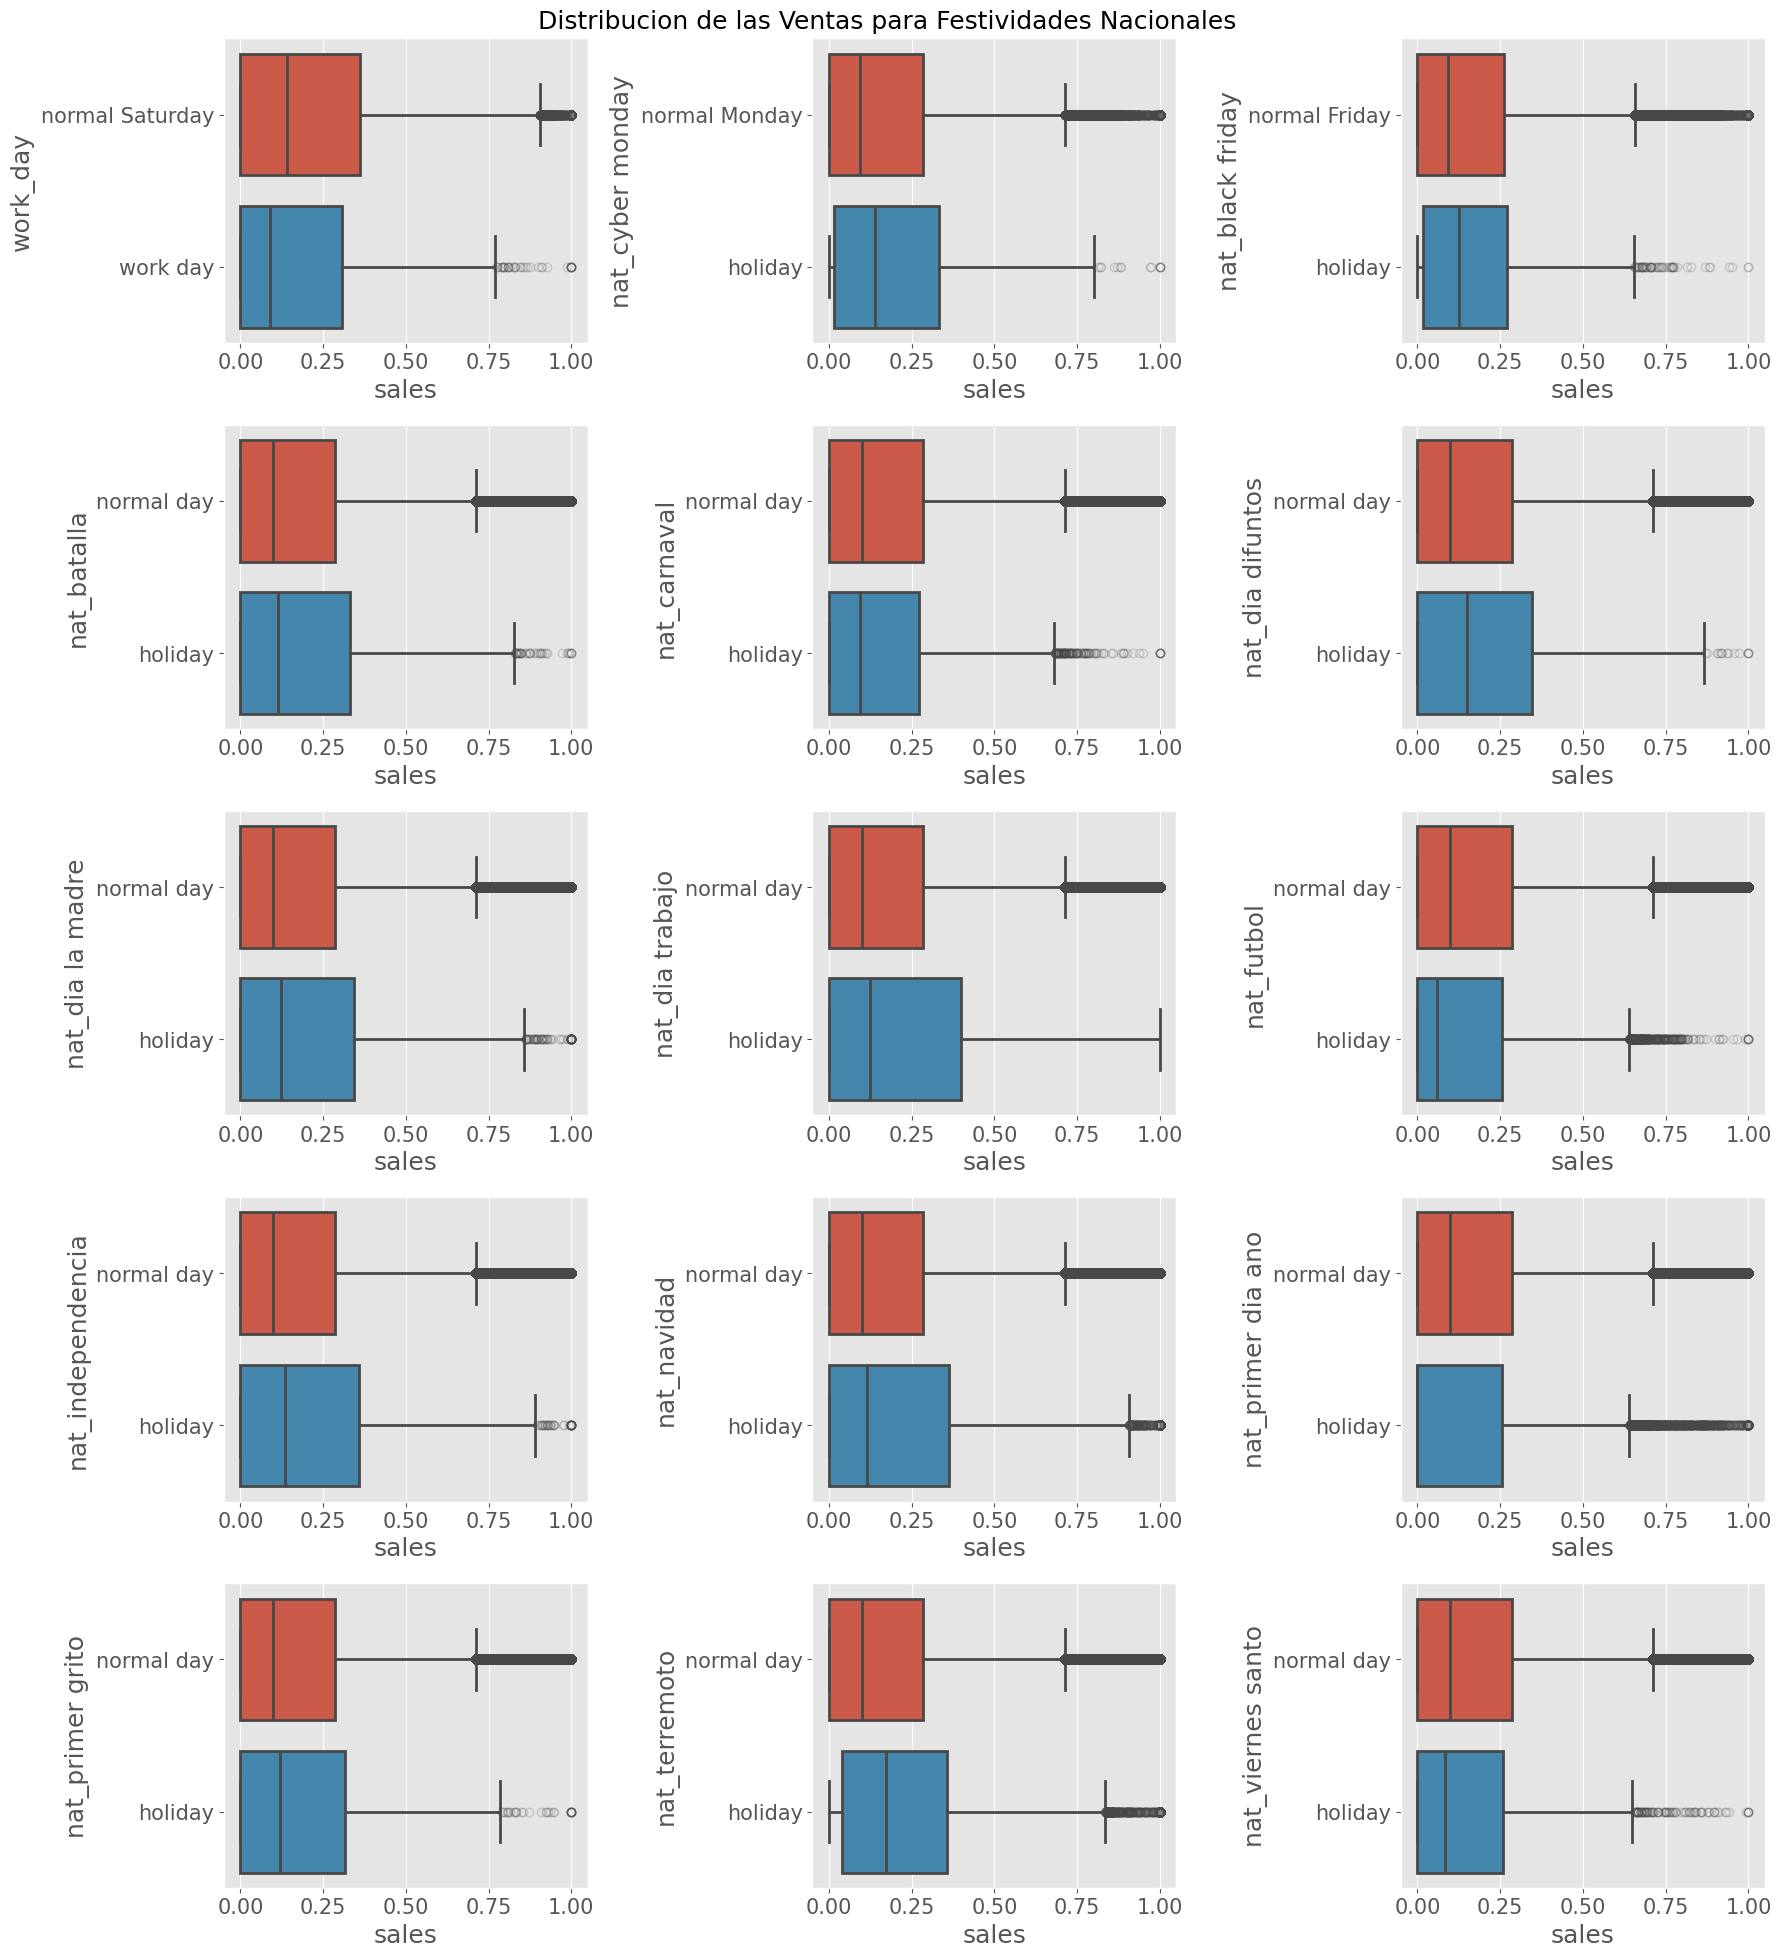

In [ ]:
def plot_national_holiday_distribution():
    df = holiday_sales_merged.copy()
    holiday_list = national_holidays.columns[1:]


    plot_kwargs = {
        "palette": COLORS[:2],
        "linewidth": 2,
        "flierprops": {"alpha": 0.2},
        "orient": "h",
    }

    fig = plt.figure(figsize=(18, 20))

    sns.boxplot(
        data=df[(df.date.dt.weekday.eq(5)) & (df.no_holiday.eq(1))],
        y="work_day",
        x="sales",
        ax=fig.add_subplot(531),
        **plot_kwargs,
    )
    plt.yticks([0, 1], ["normal Saturday", "work day"])

    sns.boxplot(
        data=df[(df.date.dt.weekday.eq(0))],
        y="nat_cyber monday",
        x="sales",
        ax=fig.add_subplot(532),
        **plot_kwargs,
    )
    plt.yticks([0, 1], ["normal Monday", "holiday"])

    sns.boxplot(
        data=df[(df.date.dt.weekday.eq(4))],
        y="nat_black friday",
        x="sales",
        ax=fig.add_subplot(533),
        **plot_kwargs,
    )
    plt.yticks([0, 1], ["normal Friday", "holiday"])

    for j, hol in enumerate(holiday_list.drop(["nat_cyber monday", "nat_black friday"])):
        sns.boxplot(
            data=df[(df[hol].eq(1)) | (df.no_holiday.eq(1))],
            y=hol,
            x="sales",
            ax=fig.add_subplot(5, 3, j+4),
            **plot_kwargs,
        )
        plt.yticks([0, 1], ["normal day", "holiday"])

    plt.suptitle("Distribucion de las Ventas para Festividades Nacionales")
    plt.tight_layout()
    plt.show()

plot_national_holiday_distribution()

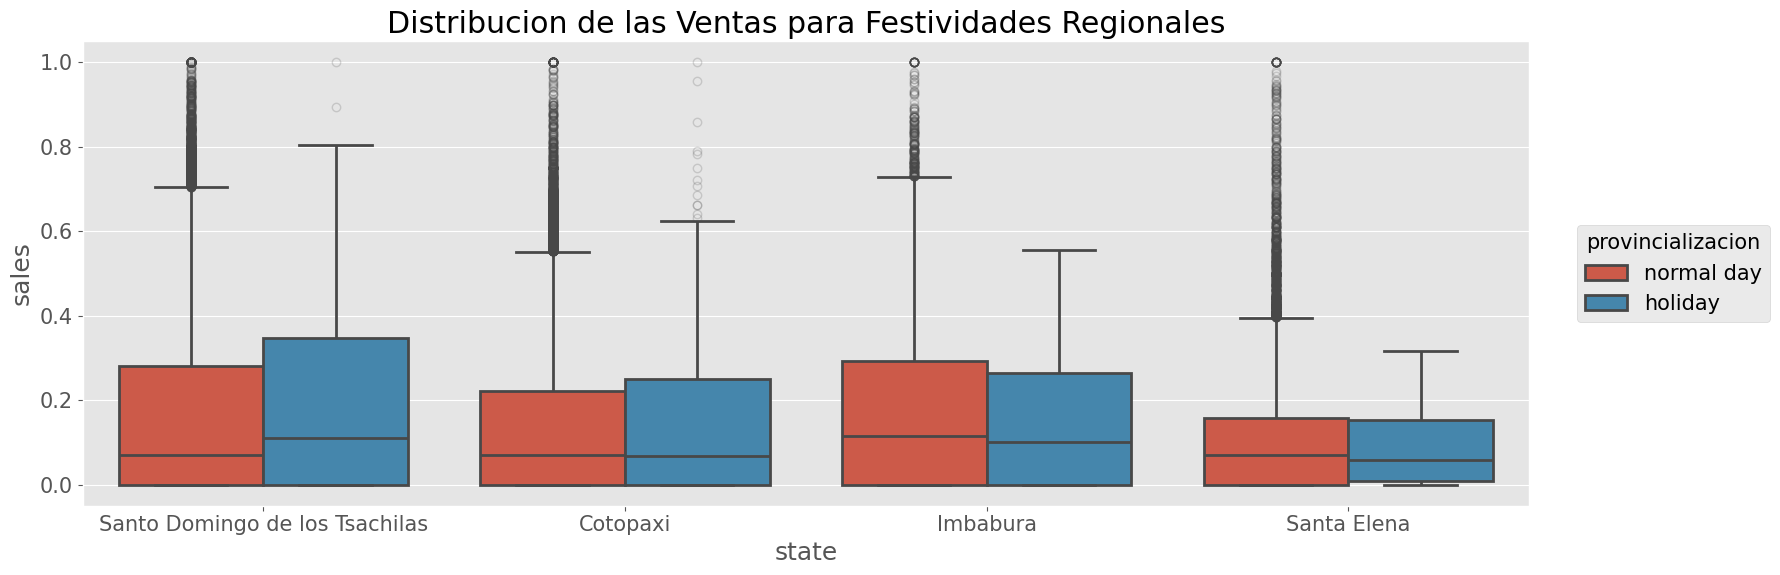

In [ ]:
def plot_regional_holiday_distribution():
    df = holiday_sales_merged.copy()
    states_with_regional_holiday = regional_holidays.state.unique()
    df = df[df.state.isin(states_with_regional_holiday)]


    fig = plt.figure(figsize=(18, 6))

    sns.boxplot(
        data=df[(df.provincializacion.eq(1)) | (df.no_holiday.eq(1))],
        x="state",
        y="sales",
        hue="provincializacion",
        palette=COLORS[:2],
        linewidth=2,
        flierprops={"alpha": 0.2},
        ax=fig.add_subplot(111),
    )
    plt.title("Distribucion de las Ventas para Festividades Regionales")
    leg = plt.legend(loc="center", title="provincializacion", bbox_to_anchor=(1.1, 0.5))
    leg.texts[0].set_text("normal day")
    leg.texts[1].set_text("holiday")

    plt.tight_layout()
    plt.show()

plot_regional_holiday_distribution()

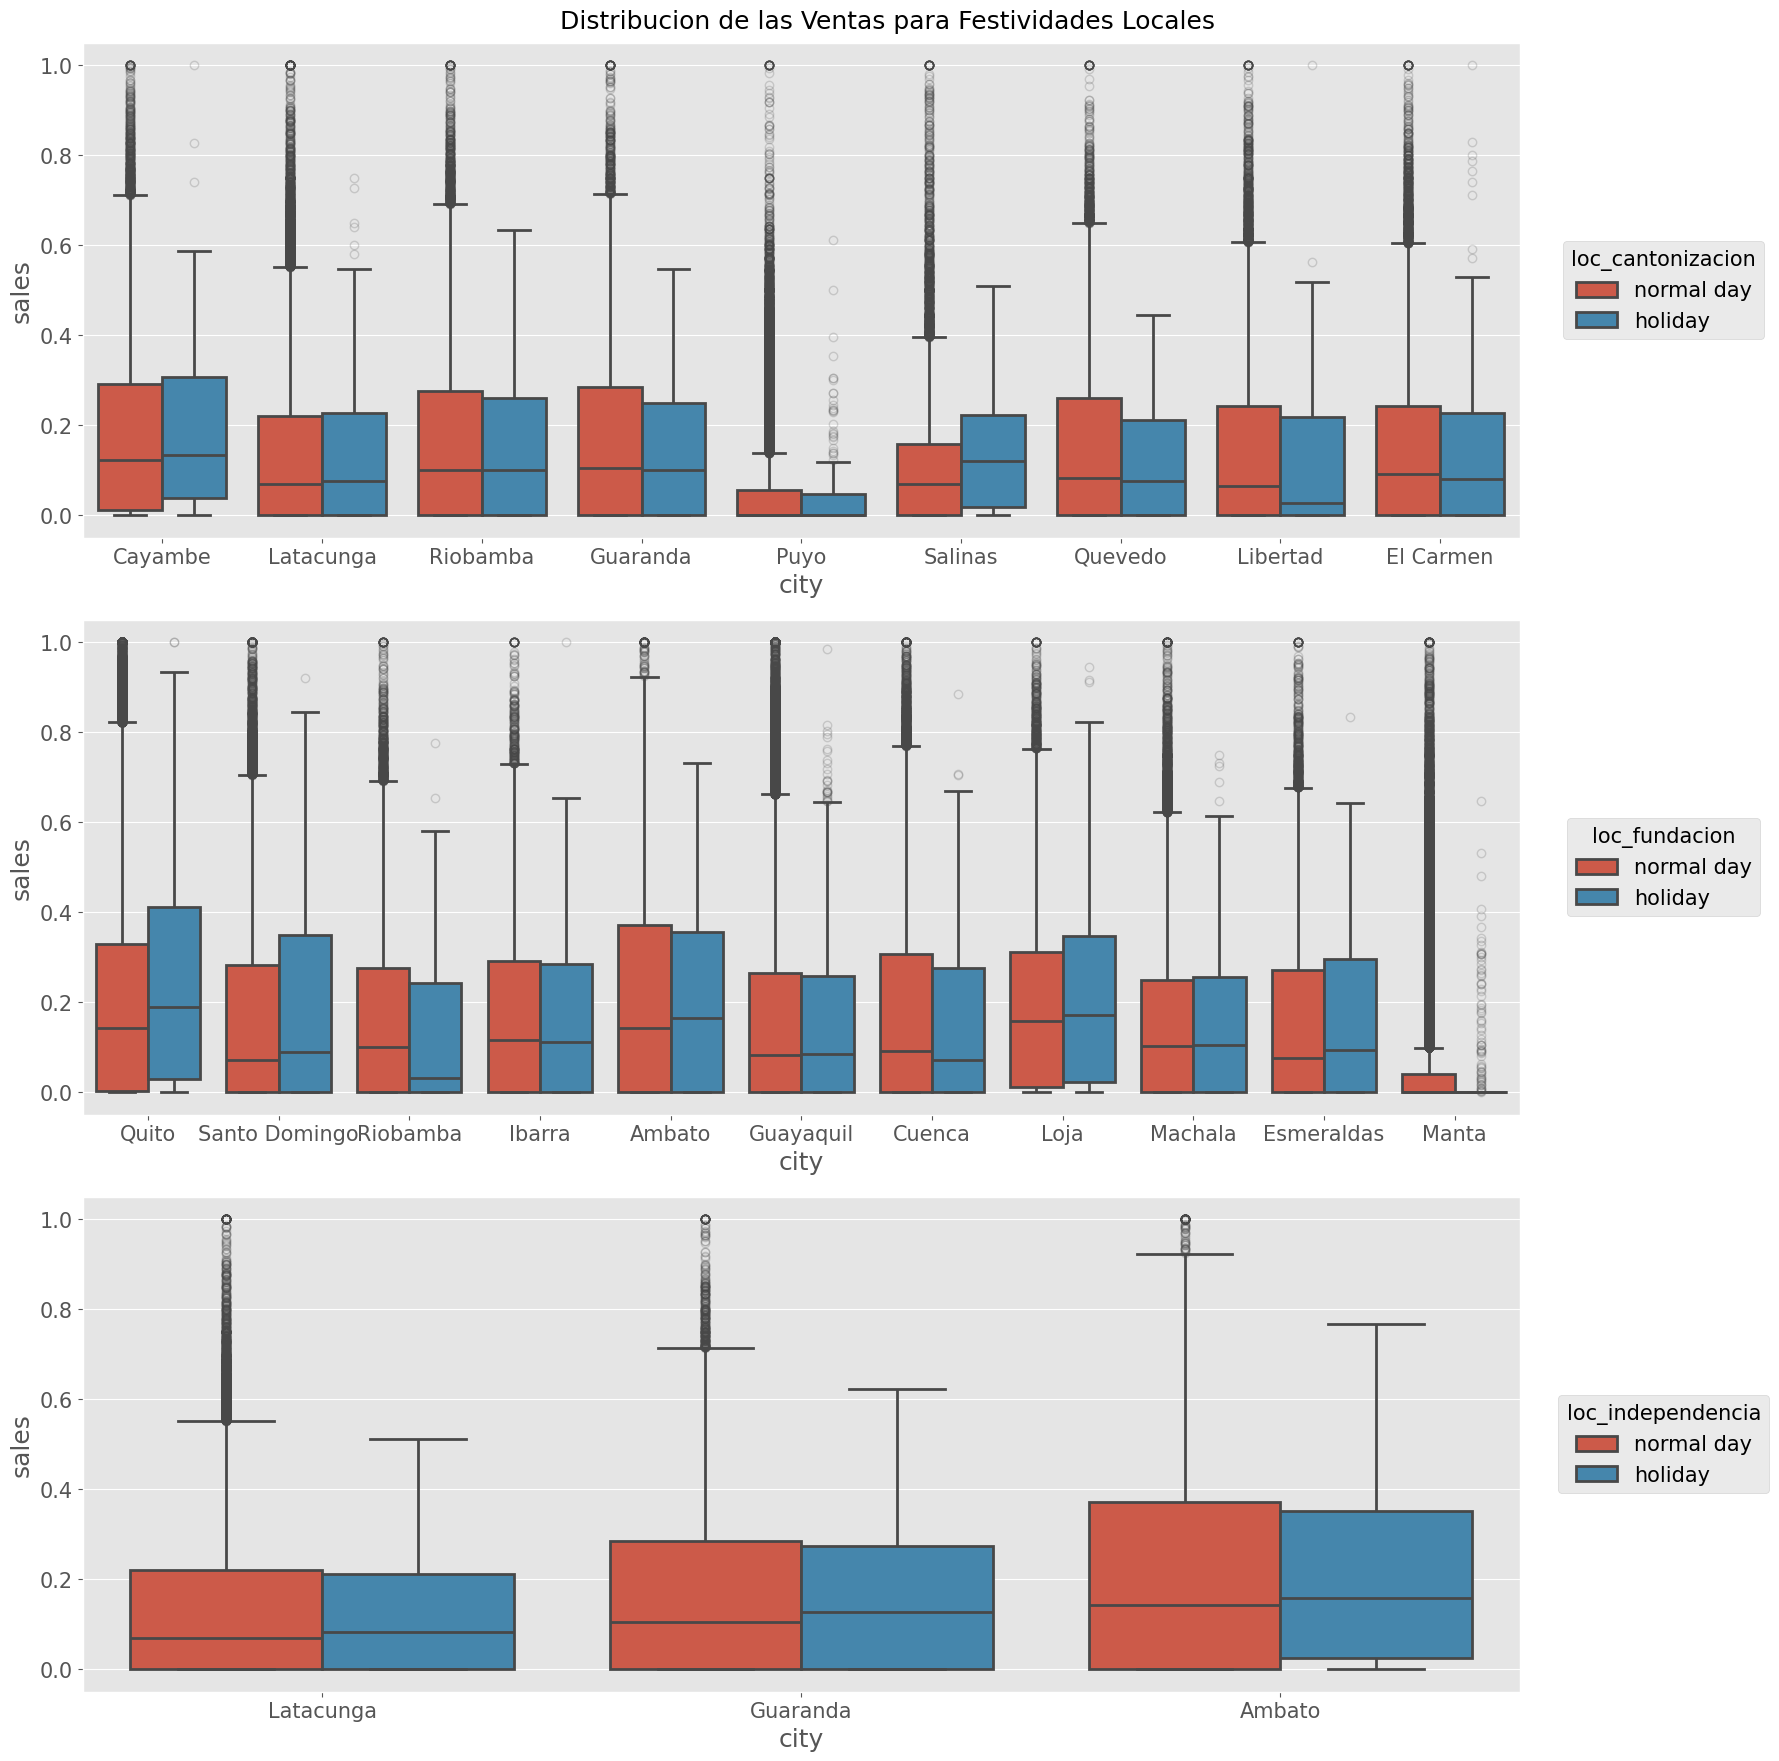

In [ ]:
def plot_local_holiday_distribution():
    df = holiday_sales_merged.copy()
    holiday_list = local_holidays.columns[2:]



    fig = plt.figure(figsize=(18, 18))

    for j, hol in enumerate(holiday_list):
        tmp = df[df.city.isin(local_holidays[local_holidays[hol].eq(1)].city.unique())]
        sns.boxplot(
            data=tmp[(tmp[hol].eq(1)) | (tmp.no_holiday.eq(1))],
            x="city",
            y="sales",
            hue=hol,
            palette=COLORS[:2],
            linewidth=2,
            flierprops={"alpha": 0.2},
            ax=fig.add_subplot(3, 1, j+1),
        )
        leg = plt.legend(loc="center", title=hol, bbox_to_anchor=(1.1, 0.5))
        leg.texts[0].set_text("normal day")
        leg.texts[1].set_text("holiday")

    plt.suptitle("Distribucion de las Ventas para Festividades Locales")
    plt.tight_layout()
    plt.show()

plot_local_holiday_distribution()

Estudio de ventas para distintos intervalos temporales

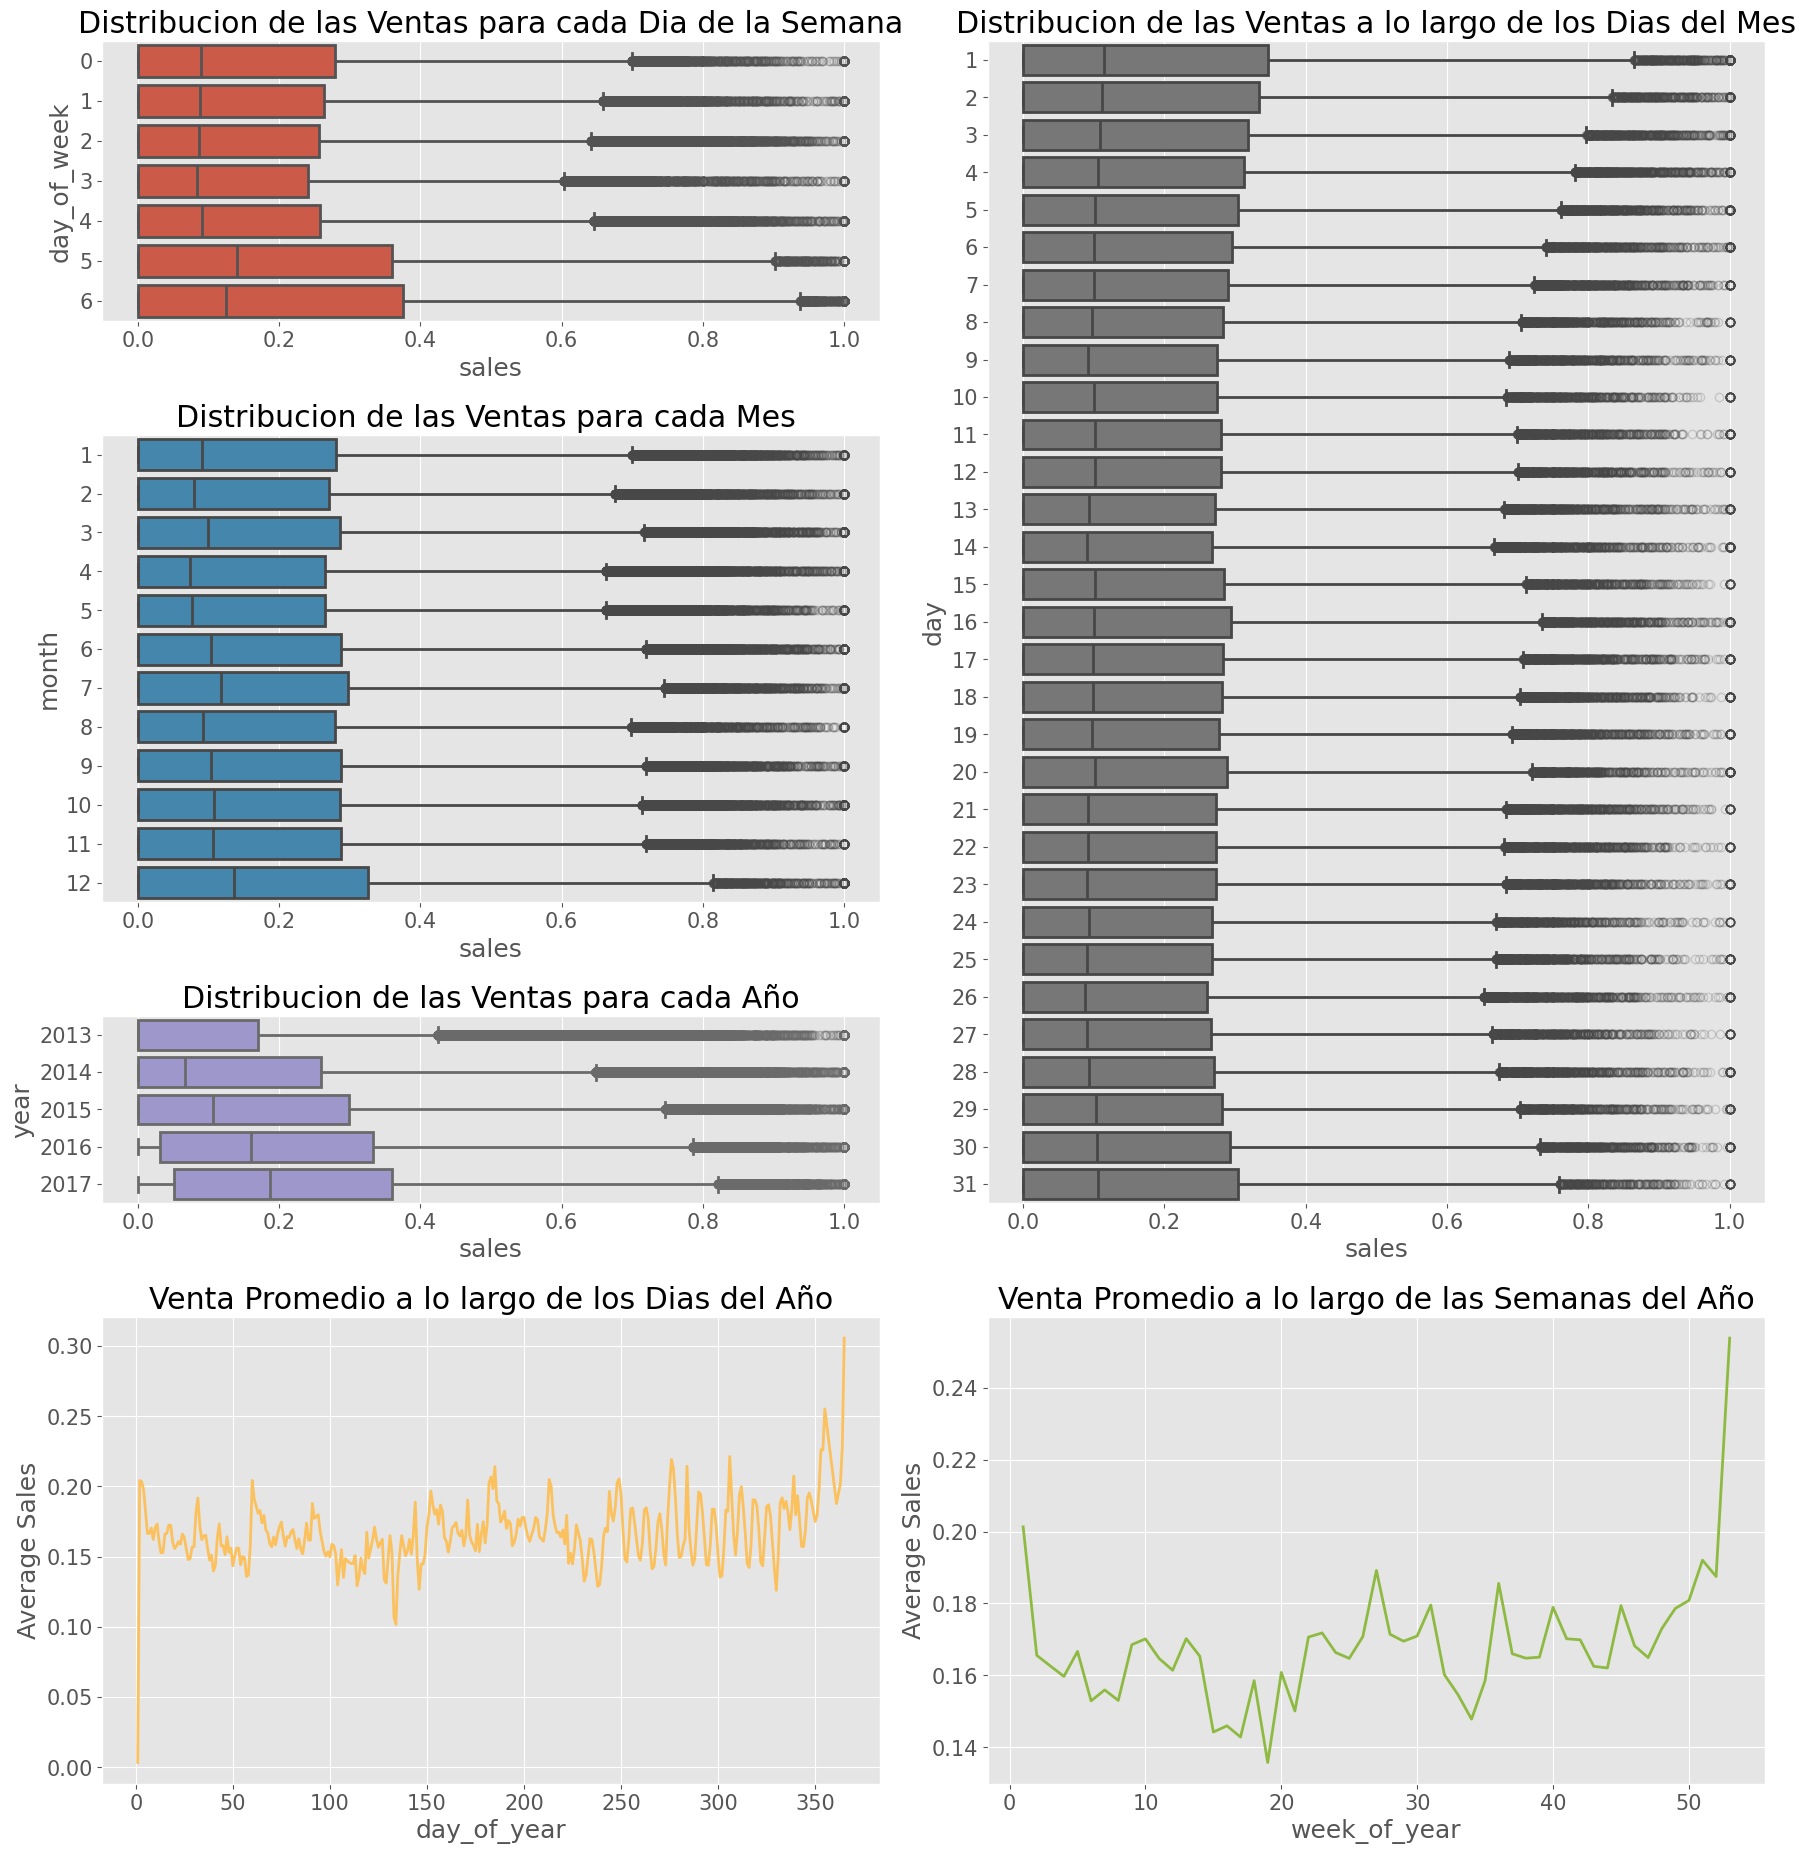

In [ ]:
def plot_date_distribution():
    df = holiday_sales_merged.copy().sort_values(["date", "store_nbr", "family"], ignore_index=True)
    df = df[df.no_holiday.eq(1)].reset_index(drop=True)
    df["day"] = df.date.dt.day
    df["month"] = df.date.dt.month
    df["year"] = df.date.dt.year
    df["day_of_week"] = df.date.dt.dayofweek
    df["day_of_year"] = df.date.dt.dayofyear
    df["week_of_year"] = df.date.dt.isocalendar().week.astype(int)
    df["date_index"] = df.date.factorize()[0]


    plot_kwargs = {
        "linewidth": 2,
        "flierprops": {"alpha": 0.2},
        "orient": "h",
    }

    fig = plt.figure(figsize=(18, 24))
    gs = fig.add_gridspec(5, 2, height_ratios=(3, 5, 2, 5, 5))

    sns.boxplot(
        data=df,
        y="day_of_week",
        x="sales",
        color=COLORS[0],
        ax=fig.add_subplot(gs[0, 0]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas para cada Dia de la Semana")

    sns.boxplot(
        data=df,
        y="month",
        x="sales",
        color=COLORS[1],
        ax=fig.add_subplot(gs[1, 0]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas para cada Mes ")

    sns.boxplot(
        data=df,
        y="year",
        x="sales",
        color=COLORS[2],
        ax=fig.add_subplot(gs[2, 0]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas para cada Año")

    sns.boxplot(
        data=df,
        y="day",
        x="sales",
        color=COLORS[3],
        ax=fig.add_subplot(gs[:3, 1]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas a lo largo de los Dias del Mes")

    sns.lineplot(
        data=df.groupby("day_of_year").sales.mean().reset_index(),
        x="day_of_year",
        y="sales",
        color=COLORS[4],
        ax=fig.add_subplot(gs[3, 0]),
        linewidth=2,
    )
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio a lo largo de los Dias del Año")

    sns.lineplot(
        data=df.groupby("week_of_year").sales.mean().reset_index(),
        x="week_of_year",
        y="sales",
        color=COLORS[5],
        ax=fig.add_subplot(gs[3, 1]),
        linewidth=2,
    )
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio a lo largo de las Semanas del Año")

    plt.tight_layout()
    plt.show()

plot_date_distribution()

Ventas por familia de producto

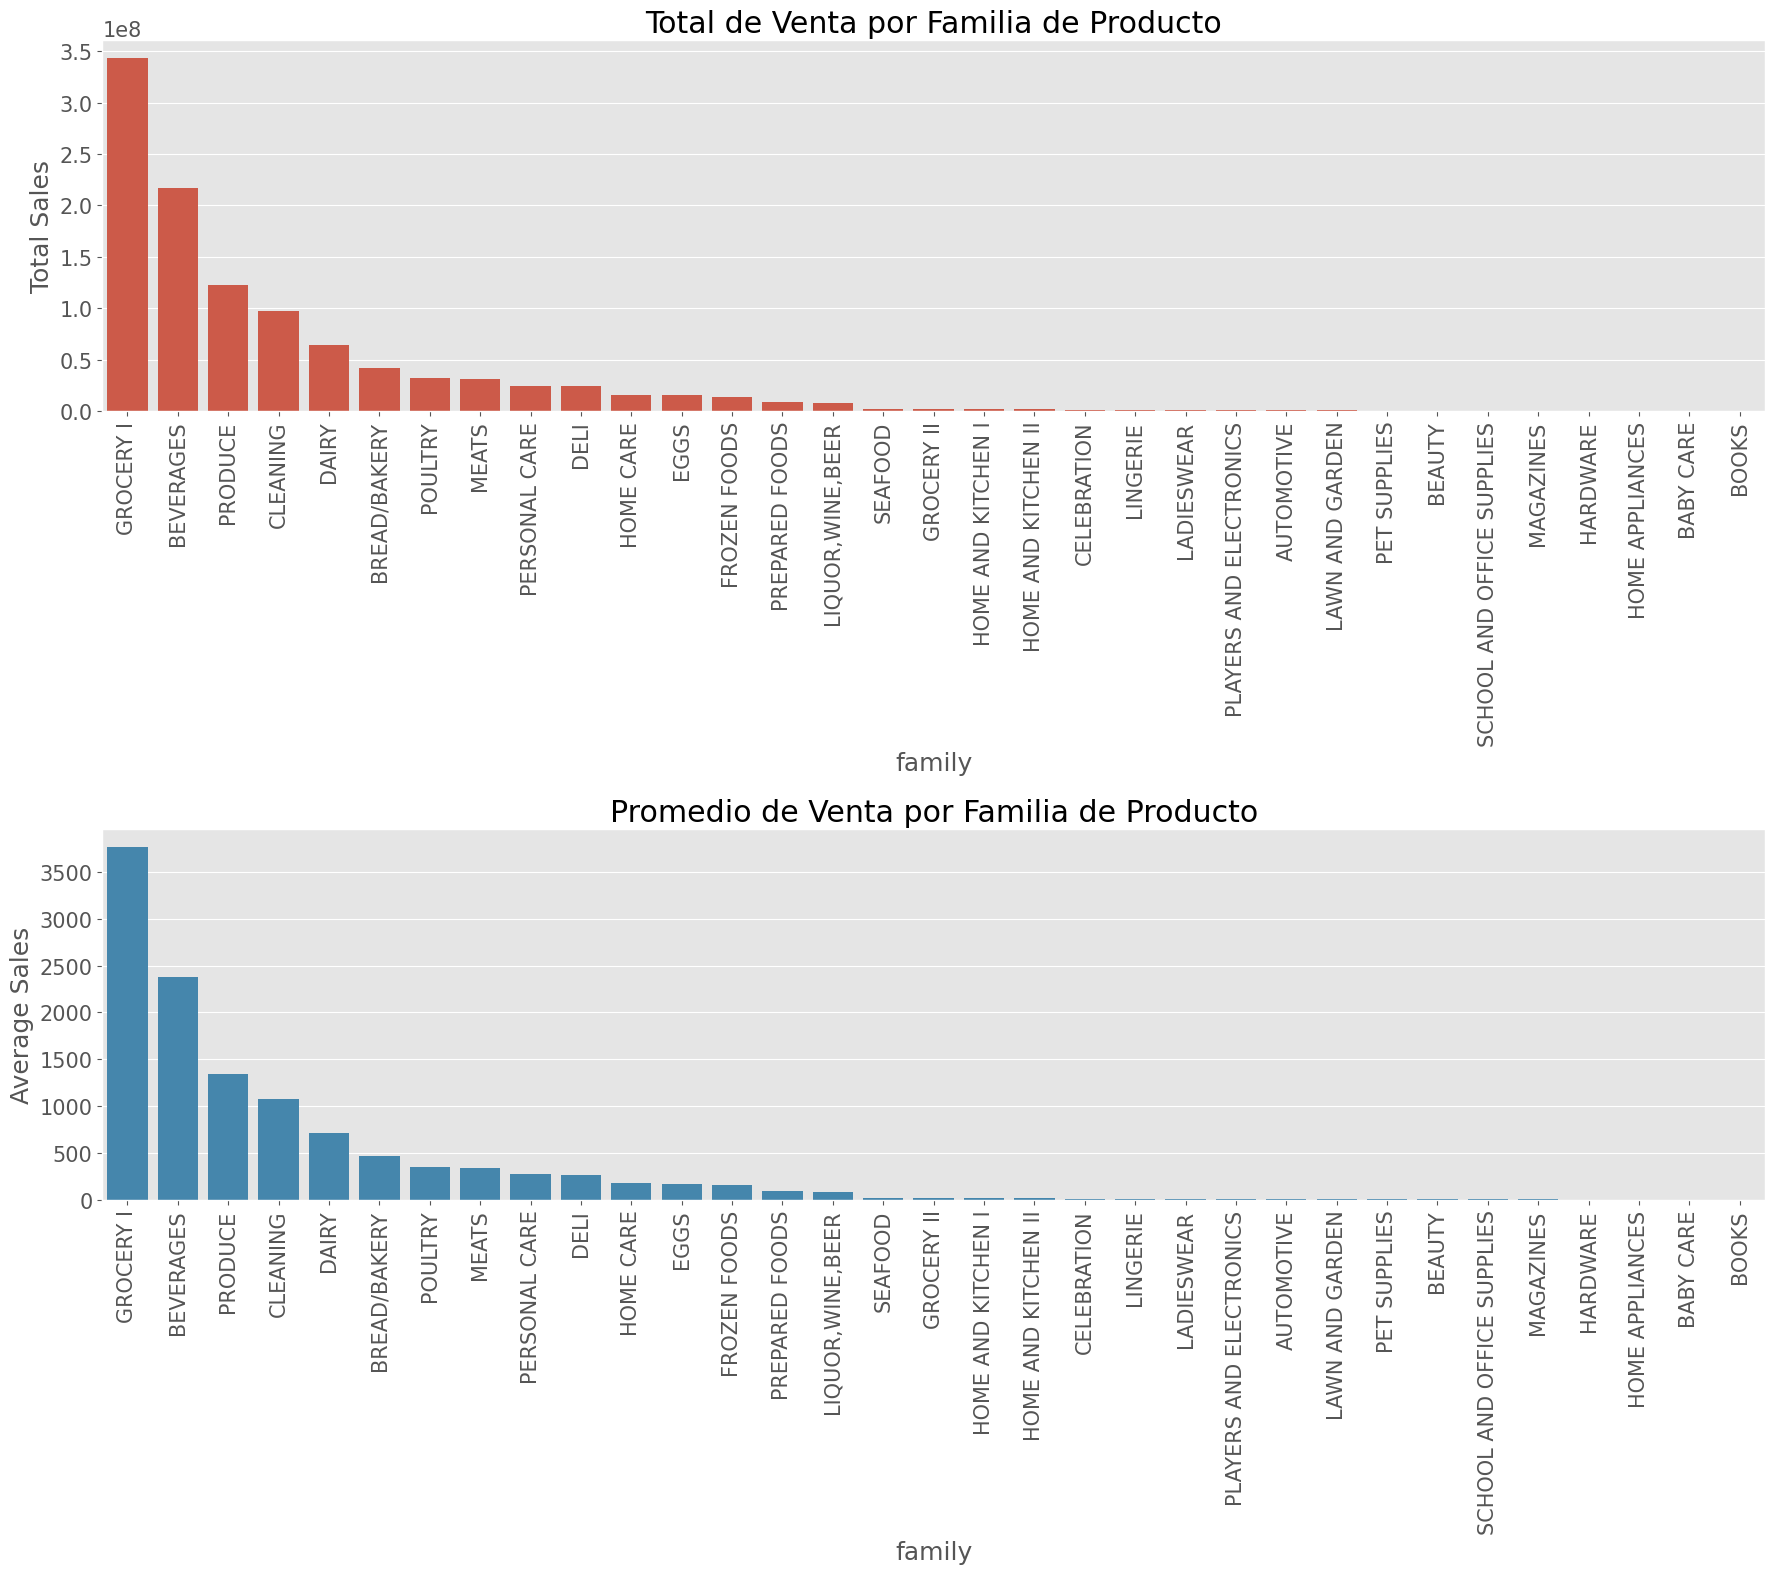

In [ ]:
family_sales = train.groupby('family')['sales'].agg(['sum', 'mean']).reset_index()
family_sales = family_sales.sort_values(by='sum', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(18, 16))

sns.barplot(data=family_sales, x='family', y='sum', ax=axes[0], color=COLORS[0])
axes[0].set_title('Total de Venta por Familia de Producto')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=90)

family_sales_mean = family_sales.sort_values(by='mean', ascending=False)
sns.barplot(data=family_sales_mean, x='family', y='mean', ax=axes[1], color=COLORS[1])
axes[1].set_title('Promedio de Venta por Familia de Producto')
axes[1].set_ylabel('Average Sales')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Estudio de venta por tienda

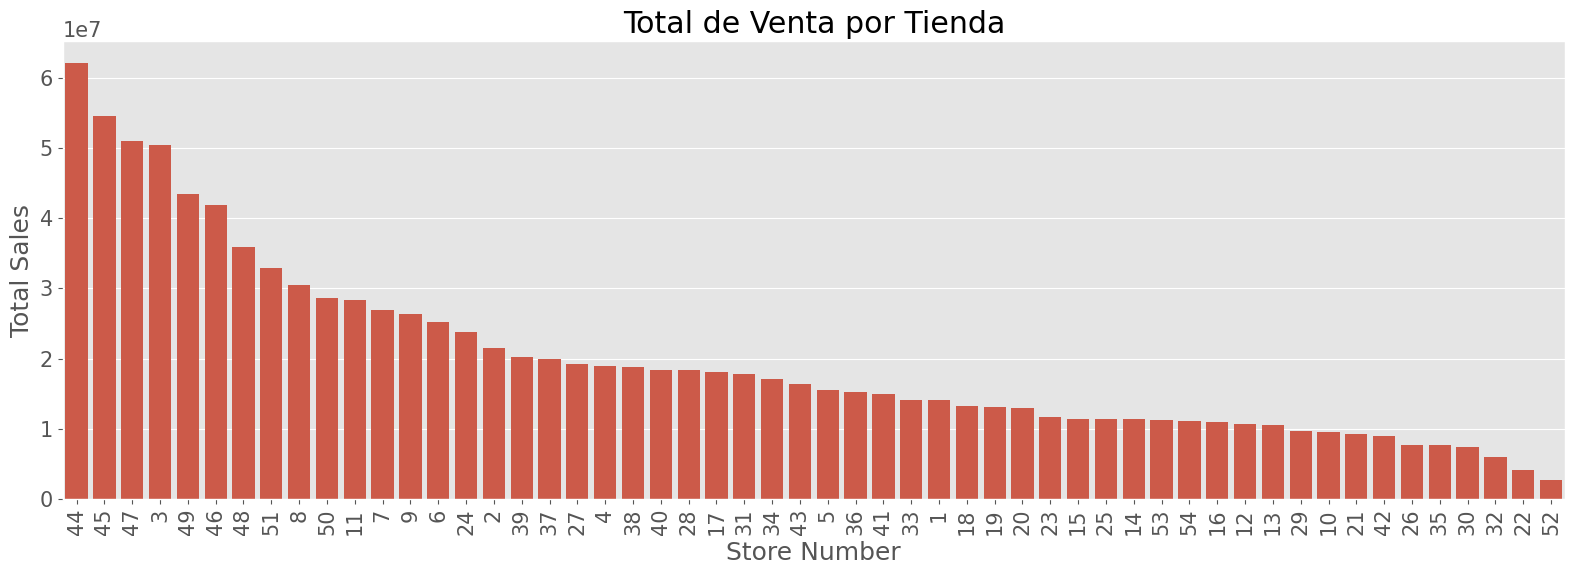

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate total sales by store and sort in descending order
store_sales_total = train.groupby('store_nbr')['sales'].sum().reset_index()
store_sales_total = store_sales_total.sort_values(by='sales', ascending=False)

# Create the bar chart
plt.figure(figsize=(16, 6))
sns.barplot(data=store_sales_total, x='store_nbr', y='sales', order=store_sales_total['store_nbr'], color=COLORS[0])
plt.title('Total de Venta por Tienda')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Analisis de clustering y PCA

In [ ]:
family_features = train.groupby('family').agg(
    total_sales=('sales', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_onpromotion=('onpromotion', 'mean')
).reset_index()

family_features.head()

,family,total_sales,avg_sales,avg_onpromotion
0,AUTOMOTIVE,554822.0,6.086778,0.052473
1,BABY CARE,10051.0,0.110266,0.000581
2,BEAUTY,337893.0,3.706918,0.147918
3,BEVERAGES,216954486.0,2380.139613,9.949952
4,BOOKS,6438.0,0.070629,0.000000


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Extract features for clustering
features = ['total_sales', 'avg_sales', 'avg_onpromotion']
X = family_features[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
family_features['cluster'] = kmeans.fit_predict(X_scaled)

family_features.head()

,family,total_sales,avg_sales,avg_onpromotion,cluster
0,AUTOMOTIVE,554822.0,6.086778,0.052473,0
1,BABY CARE,10051.0,0.110266,0.000581,0
2,BEAUTY,337893.0,3.706918,0.147918,0
3,BEVERAGES,216954486.0,2380.139613,9.949952,1
4,BOOKS,6438.0,0.070629,0.000000,0


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA to reduce features to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
family_features['pca_1'] = pca_components[:, 0]
family_features['pca_2'] = pca_components[:, 1]



In [ ]:
cluster_summary = family_features.groupby('cluster').agg(
    Mean_Total_Sales=('total_sales', 'mean'),
    Mean_Avg_Daily_Sales=('avg_sales', 'mean'),
    Mean_Avg_Promotions=('avg_onpromotion', 'mean'),
    Product_Families=('family', lambda x: ', '.join(x))
).reset_index()

display(cluster_summary)

,cluster,Mean_Total_Sales,Mean_Avg_Daily_Sales,Mean_Avg_Promotions,Product_Families
0,0,6.241145e+06,68.469649,0.660972,"AUTOMOTIVE, BABY CARE, BEAUTY, BOOKS, CELEBRAT..."
1,1,1.698296e+08,1863.147110,11.107156,"BEVERAGES, PRODUCE"
2,2,5.706332e+07,626.023746,6.320402,"BREAD/BAKERY, CLEANING, DAIRY, DELI"
3,3,3.434627e+08,3768.021929,21.006681,GROCERY I


In [ ]:
import plotly.express as px

# Convert cluster to string to treat it as categorical
family_features['cluster_str'] = family_features['cluster'].astype(str)

fig = px.scatter(
    family_features,
    x='pca_1',
    y='pca_2',
    color='cluster_str',
    hover_data=['family'],
    title='Clusters de Familia de Productos por Venta y Promociones (PCA)',
    labels={'pca_1': 'Principal Component 1', 'pca_2': 'Principal Component 2', 'cluster_str': 'Cluster'}
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.show()


## Extract PCA Loadings



In [ ]:
pca_loadings = pd.DataFrame(
    pca.components_,
    columns=['total_sales', 'avg_sales', 'avg_onpromotion'],
    index=['PC1', 'PC2']
)

display(pca_loadings)

,total_sales,avg_sales,avg_onpromotion
PC1,0.581028,0.581028,0.569923
PC2,-0.402996,-0.402996,0.821698
